In [ ]:
!pip install kagglehub tensorflow matplotlib --quiet

import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
import kagglehub, os, json, time, random, glob
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Download dataset (auto-cached locally)
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# Adjust folder paths
path = ".." + path + "/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_path = path + "/train"
val_path   = path + "/valid"

print("✅ Train Path:", train_path)
print("✅ Validation Path:", val_path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
✅ Train Path: ../kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
✅ Validation Path: ../kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [ ]:
IMG_SIZE = (224, 224)
BATCH = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

# ✅ Save class names before taking subsets
class_names = train_ds.class_names
print("🌿 Classes:", len(class_names))

# ✅ Take small subset for 2–3 min quick training
train_ds = train_ds.take(10)   # only 10 batches (~320 images)
val_ds = val_ds.take(5)        # only 5 batches (~160 images)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
🌿 Classes: 38


In [ ]:
# Enable mixed precision for faster GPU/CPU compute
mixed_precision.set_global_policy('mixed_float16')

# Speed up pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(len(class_names), activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(3e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
os.makedirs("models", exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
]

start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=2, batch_size=64, callbacks=callbacks, verbose=1)
print(f"✅ Training finished in {(time.time()-start)/60:.2f} min")

Epoch 1/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 124s 12s/step - accuracy: 0.0462 - loss: 3.6606 - val_accuracy: 0.0250 - val_loss: 3.6219
Epoch 2/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 109s 11s/step - accuracy: 0.0983 - loss: 3.4847 - val_accuracy: 0.0562 - val_loss: 3.4940
✅ Training finished in 3.90 min


5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 7s/step - accuracy: 0.0478 - loss: 3.4828
🌿 Validation Accuracy: 5.62%


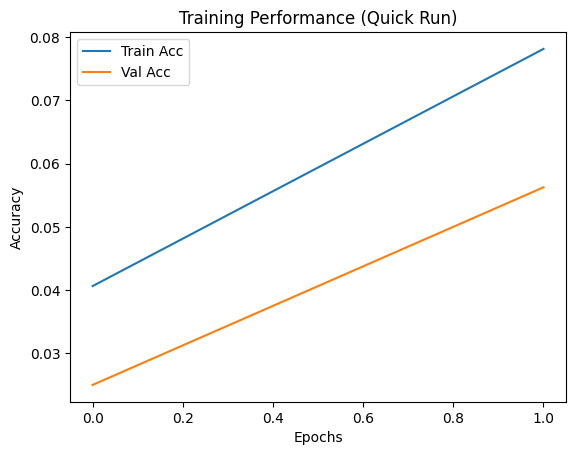

In [ ]:
loss, acc = model.evaluate(val_ds)
print(f"🌿 Validation Accuracy: {acc*100:.2f}%")

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.title("Training Performance (Quick Run)")
plt.show()

In [ ]:
model.save("models/efficientnet_quickdemo.h5")
with open("models/class_names.json", "w") as f:
    json.dump(class_names, f)
print("✅ Model & labels saved successfully!")

✅ Model & labels saved successfully!


🖼️ Testing on: ../kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Corn_(maize)___Northern_Leaf_Blight/d0aa3b59-046b-490d-a333-8049b87d5db9___RS_NLB 4147 copy.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


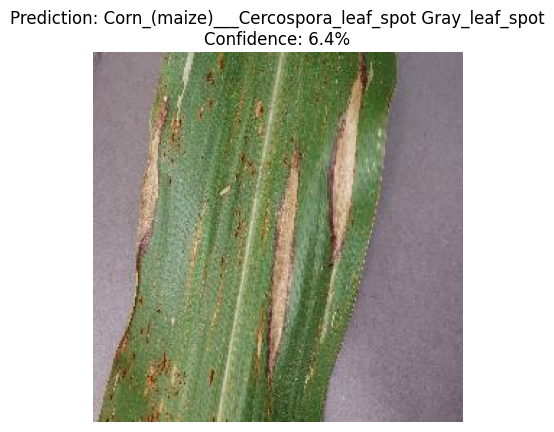

In [ ]:
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model("models/efficientnet_quickdemo.h5")
with open("models/class_names.json") as f:
    class_names = json.load(f)

# Pick a random validation image
sample_image = random.choice(glob.glob(val_path + "/*/*.jpg"))
print("🖼️ Testing on:", sample_image)

img = image.load_img(sample_image, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0]
label = class_names[np.argmax(pred)]
confidence = np.max(pred)

plt.imshow(image.load_img(sample_image))
plt.axis('off')
plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.1f}%")
plt.show()